## Manipulate same data using Pandas

#### # Notice how faster and more concise it is

#### Importing libraries

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#### Importing the Data

In [3]:
df = pd.read_csv('temperatures.csv', sep=',')

In [4]:
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y%m%d')
df['YEAR'] = df['DATE'].dt.year
df['MONTH'] = df['DATE'].dt.month

In [5]:
df.head()

,CITY,TEMP,DATE,YEAR,MONTH
0,SEATTLE,3.10,1961-01-01,1961,1
1,SEATTLE,0.55,1961-01-02,1961,1
2,SEATTLE,0.00,1961-01-03,1961,1
3,SEATTLE,4.45,1961-01-04,1961,1
4,SEATTLE,8.35,1961-01-05,1961,1


In [6]:
cities = df['CITY'].unique()
avgTemps = df.groupby('CITY', sort=False)['TEMP'].mean()
cityLabels = cities.map(lambda c: c[0:2])
cityPts = np.arange(len(cityLabels))
avgTempsF = avgTemps.map(lambda c: c * 9/5 + 32)

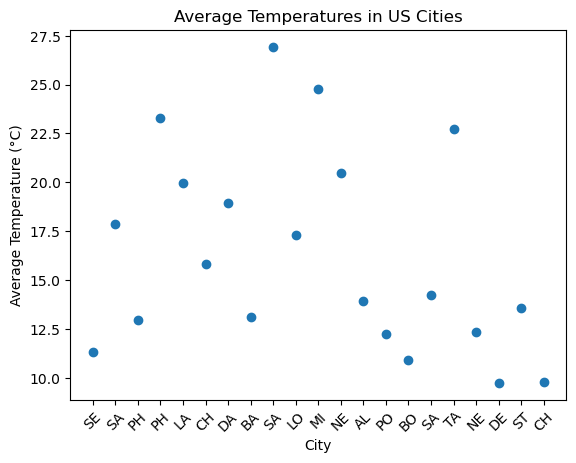

In [7]:
plt.scatter(cityPts, avgTemps)
plt.title('Average Temperatures in US Cities')
plt.xlabel('City')
plt.ylabel('Average Temperature (°C)')
plt.xticks(cityPts, cityLabels, rotation=45)
plt.show()

In [40]:
mean_data = df.groupby(['CITY', 'YEAR'], sort=False)['TEMP'].mean()

In [41]:
mean_data_long = mean_data.reset_index()
mean_data_long.head()

,CITY,YEAR,TEMP
0,SEATTLE,1961,11.123699
1,SEATTLE,1962,10.547808
2,SEATTLE,1963,11.007945
3,SEATTLE,1964,10.006011
4,SEATTLE,1965,11.428630


In [42]:
mean_data_wide = mean_data.unstack(level=0)
mean_data_wide.head()

CITY,SEATTLE,SAN DIEGO,PHILADELPHIA,PHOENIX,LAS VEGAS,CHARLOTTE,DALLAS,BALTIMORE,SAN JUAN,LOS ANGELES,...,NEW ORLEANS,ALBUQUERQUE,PORTLAND,BOSTON,SAN FRANCISCO,TAMPA,NEW YORK,DETROIT,ST LOUIS,CHICAGO
YEAR,,,,,,,,,,,,,,,,,,,,,
1961,11.123699,17.510274,11.559041,21.250959,18.751644,15.462877,18.058630,12.543288,25.922877,16.821370,...,19.627945,13.104110,12.178767,10.606164,13.940411,22.738219,12.013151,9.560822,12.161781,9.174658
1962,10.547808,16.727260,11.216027,21.456438,19.287671,15.463836,18.829589,12.076027,25.831370,16.165342,...,20.100411,13.497671,11.671370,9.967534,13.246712,21.958082,11.085479,8.691096,12.583425,9.000822
1963,11.007945,17.550411,11.123288,21.653014,18.930000,15.367808,19.293014,11.862877,26.123699,17.421370,...,19.559178,14.066301,11.175753,10.634521,13.532192,21.694932,11.564932,8.305068,12.448767,8.467534
1964,10.006011,16.750956,12.286066,19.943989,18.242760,15.529645,18.429918,12.851230,26.444672,16.018989,...,19.581011,12.567486,10.053279,10.110929,13.549180,22.081967,11.943989,8.984426,13.341530,9.366940
1965,11.428630,17.004521,11.714932,20.386301,18.407123,15.862603,18.993151,12.505753,26.171370,16.527123,...,19.891370,13.312055,12.073973,9.839315,13.080959,22.030411,11.325890,9.098356,13.398493,8.920959


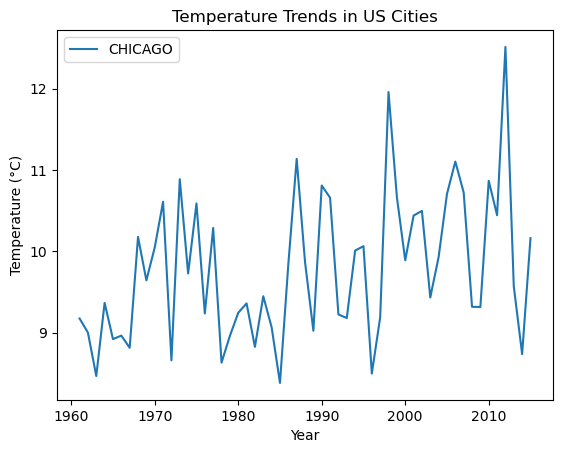

In [ ]:
chicago = mean_data_long[mean_data_long['CITY'] == 'CHICAGO']
plt.plot(chicago['YEAR'], chicago['TEMP'], label='CHICAGO')
plt.legend()
plt.title('Temperature Trends in US Cities')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.show()

## Get Temp Avgs for every City by Year

#### Using Pandas built in plot function

Text(0.5, 1.0, 'Temperature Trends in US Cities')

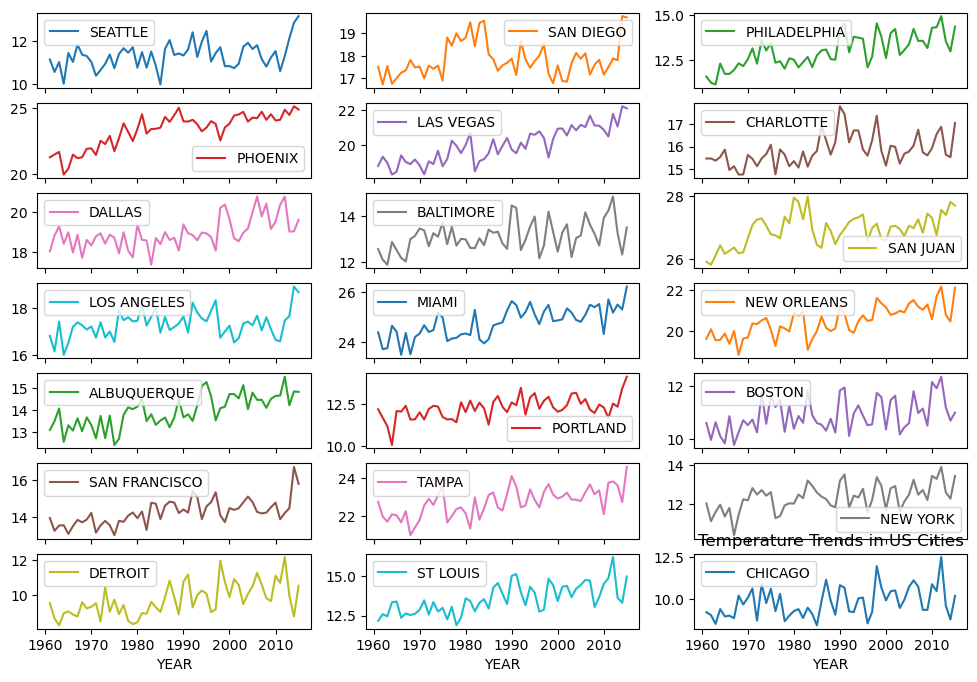

In [ ]:
mean_data_wide.plot(subplots=True, layout=(7, 3), figsize=(12, 8), sharex=True)
plt.title('Temperature Trends in US Cities')
plt.show()

#### Using Matplotlib and For loop

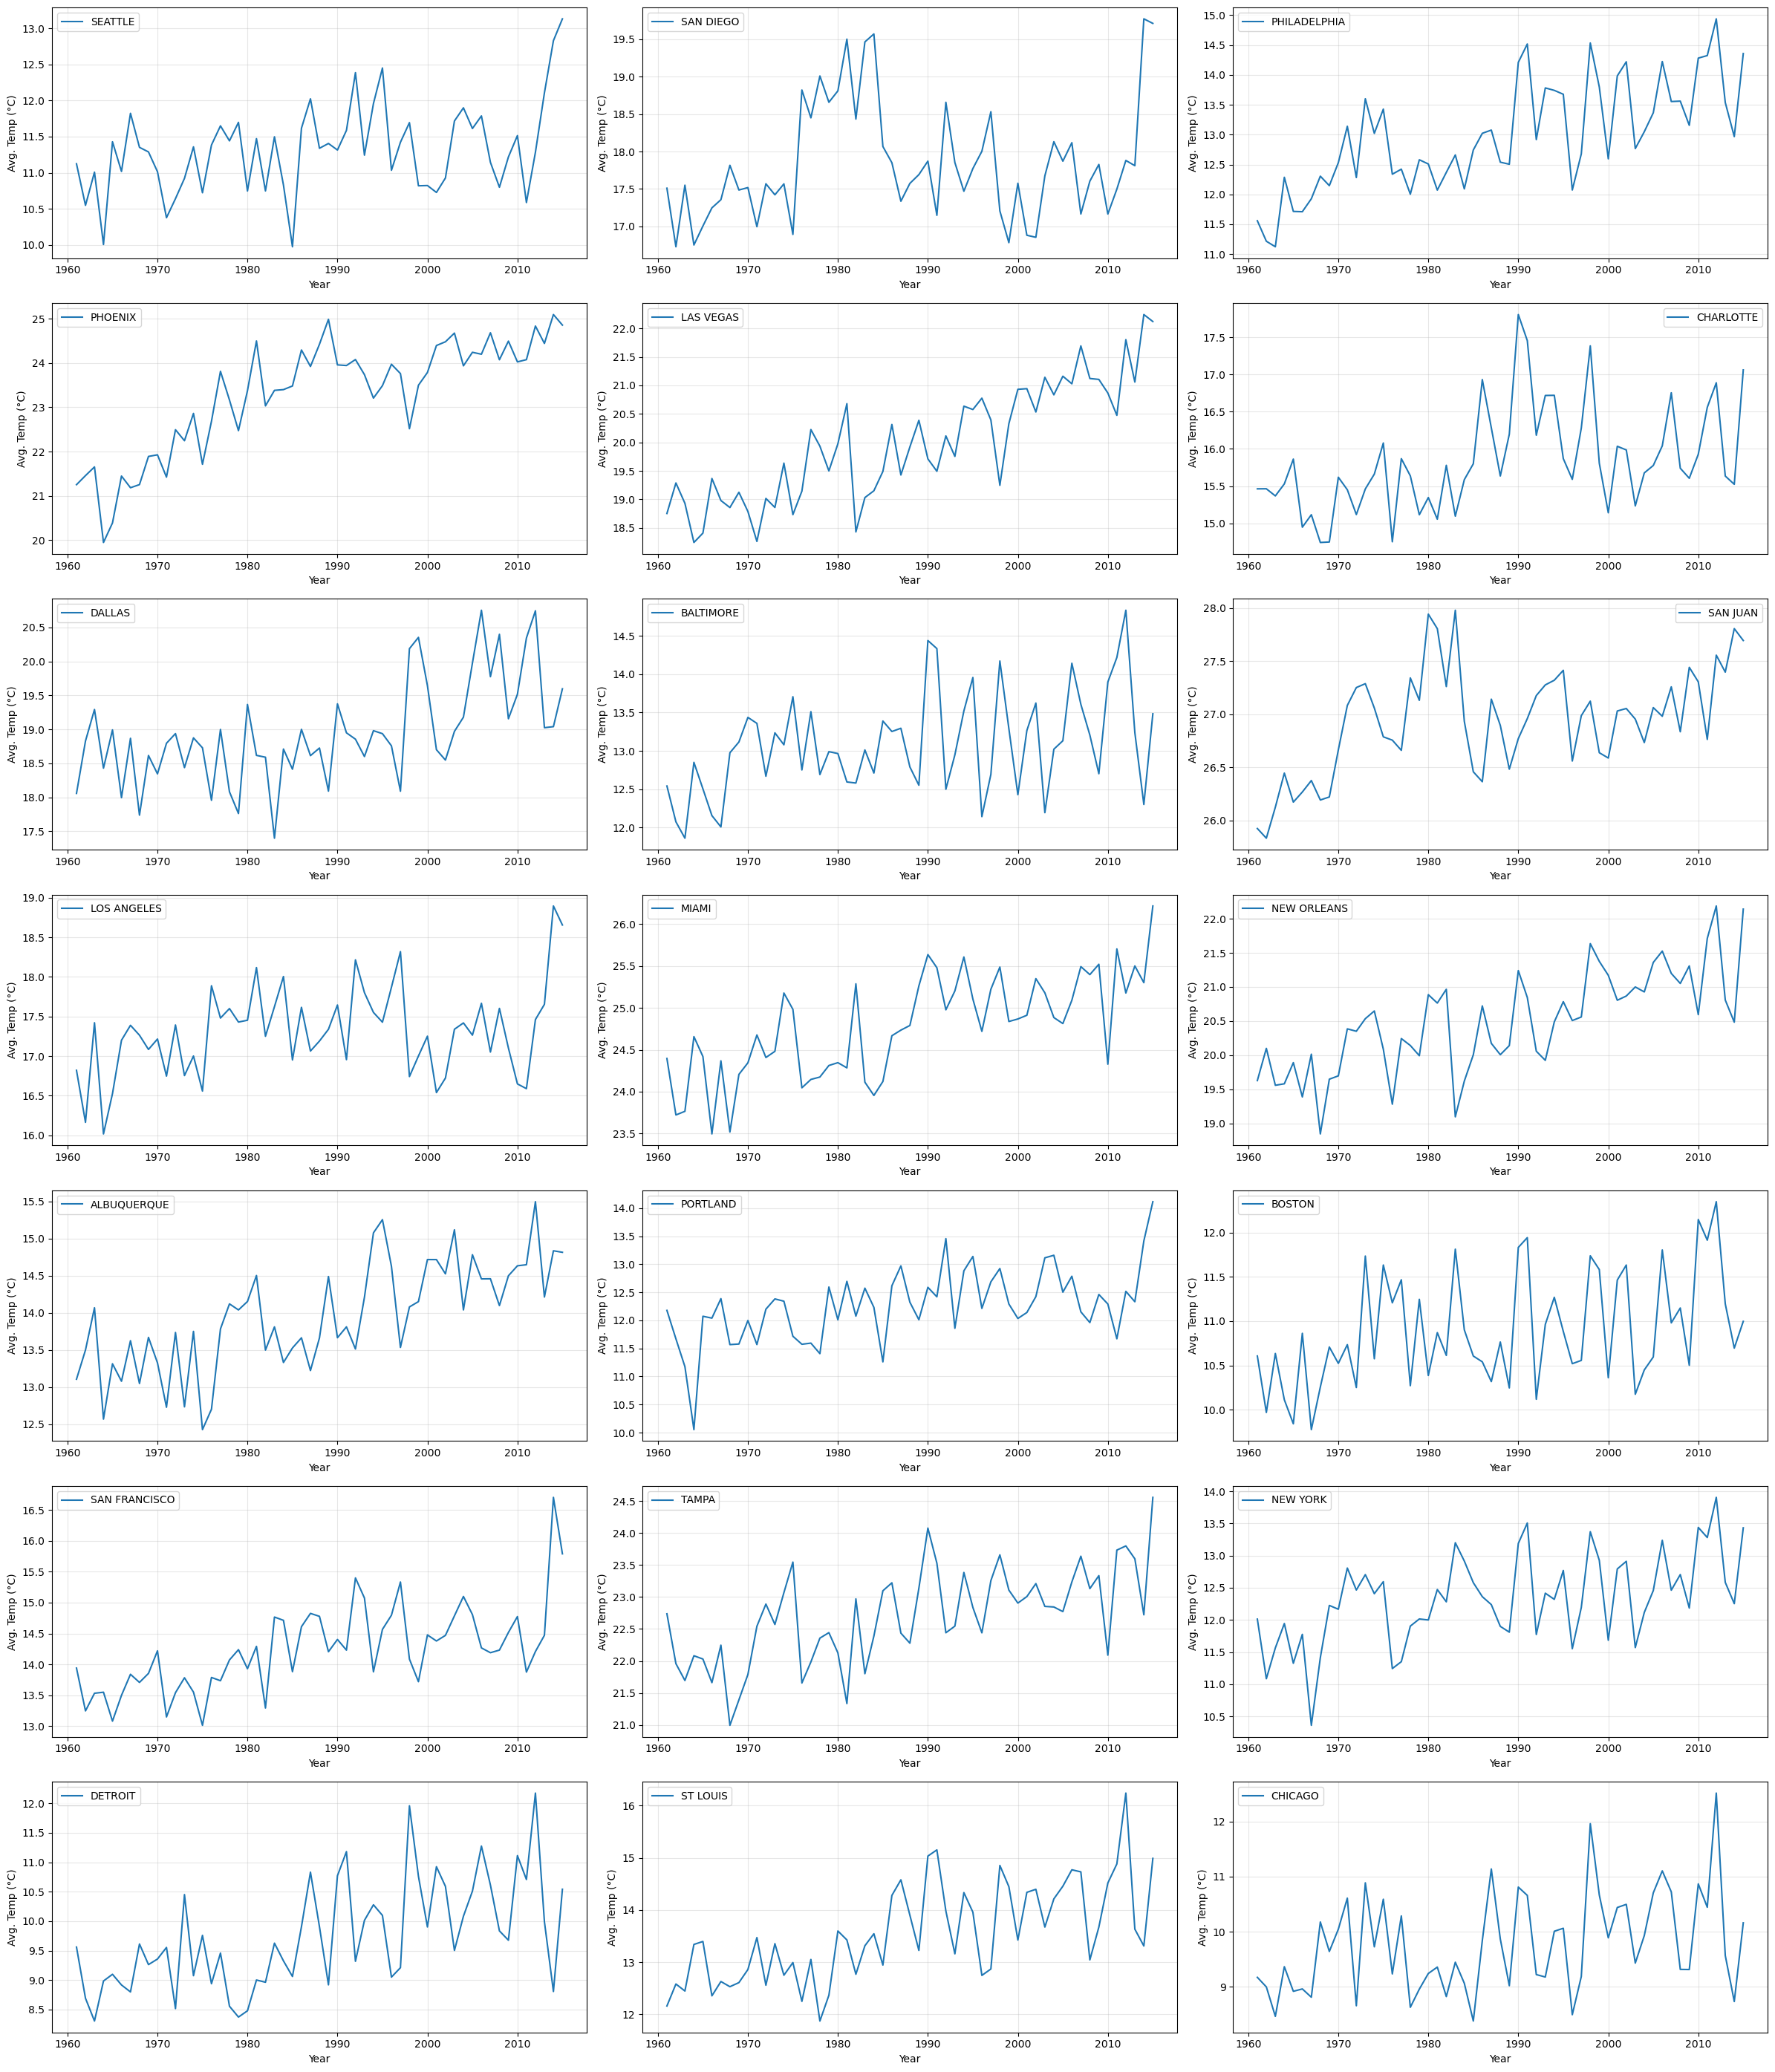

In [ ]:
cities = mean_data_wide.columns

fig, axes = plt.subplots(nrows=len(cities)//3, ncols=3, figsize=(8 * 3, 4 * 7))

for i, city in enumerate(cities):
    axes.flatten()[i].plot(mean_data_wide.index, mean_data_wide[city], label=city)
    axes.flatten()[i].set_xlabel("Year")
    axes.flatten()[i].set_ylabel("Avg. Temp (°C)")
    axes.flatten()[i].grid(True, alpha=0.3)
    axes.flatten()[i].legend()
plt.tight_layout()
plt.show()

In [37]:
max_data = df.groupby(['CITY', 'YEAR'])['TEMP'].max()
min_data = df.groupby(['CITY', 'YEAR'])['TEMP'].min()

max_data_long = max_data.reset_index()
min_data_long = min_data.reset_index()

max_data_wide = max_data.unstack(level=0)
min_data_wide = min_data.unstack(level=0)

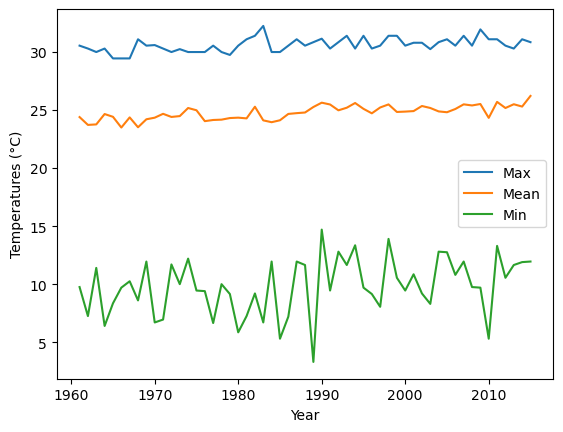

In [45]:
plt.plot(max_data_wide.index, max_data_wide['MIAMI'], label='Max')
plt.plot(mean_data_wide.index, mean_data_wide['MIAMI'], label='Mean')
plt.plot(min_data_wide.index, min_data_wide['MIAMI'], label='Min')
plt.xlabel('Year')
plt.ylabel('Temperatures (°C)')
plt.legend()
plt.show()

#### Using Seaborn for ploting histograms

In [48]:
import seaborn as sns

In [60]:
city = 'MIAMI'
year1 = 1961
year2 = 2015
city_data = df[(df['CITY'] == city) & (df['YEAR'].isin([year1, year2]))]

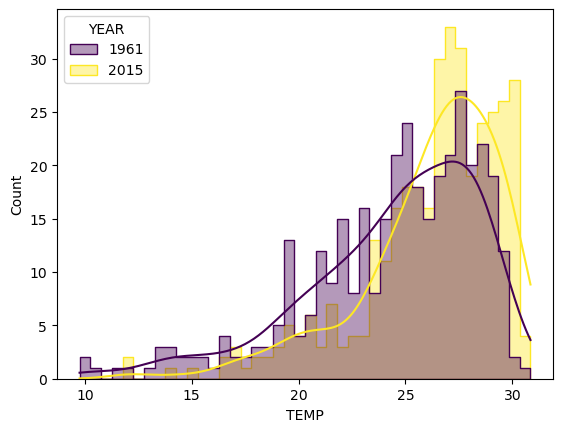

In [61]:
sns.histplot(data=city_data, x='TEMP', hue='YEAR', kde=True, alpha=0.4,          # Providnost (0 je skroz providno, 1 je puno)
    binwidth=0.5, palette='viridis', element='step')
plt.show()